In [1]:
!pip install selectivesearch

  Preparing metadata (setup.py) ... done
  Created wheel for selectivesearch: filename=selectivesearch-0.4-py3-none-any.whl size=4336 sha256=d9182692b9fa0c7b99cc0beb7b939f31ae30a003c05bc94237d1e3893b37263f
  Stored in directory: /root/.cache/pip/wheels/7f/9b/c7/58b71f1e9fe4aa0ef8affd1c673f8818bc22a5091ea8cbbe93
Successfully built selectivesearch


In [10]:
import selectivesearch
import cv2
import matplotlib.pyplot as plt
import os
%matplotlib inline

In [19]:
!mkdir /content/data
!wget -O /content/data/audrey01.jpg https://raw.githubusercontent.com/chulminkw/DLCV/master/data/image/audrey01.jpg

--2026-08-14 09:52:18--  https://raw.githubusercontent.com/chulminkw/DLCV/master/data/image/audrey01.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30102 (29K) [image/jpeg]
Saving to: ‘/content/data/audrey01.jpg’

/content/data/audre 100%[===================>]  29.40K  --.-KB/s    in 0.002s  

2026-08-14 09:52:19 (12.4 MB/s) - ‘/content/data/audrey01.jpg’ saved [30102/30102]



img shape: (450, 375, 3)


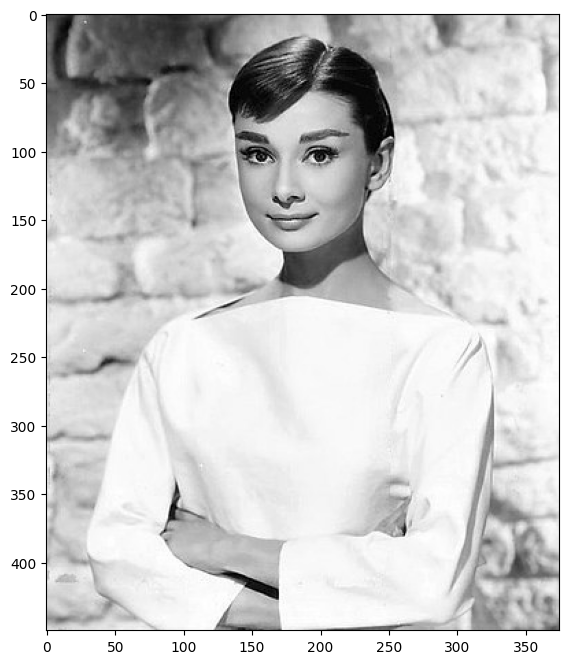

In [20]:
img = cv2.imread('./data/audrey01.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
print('img shape:', img.shape)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.show()

In [23]:
_, regions = selectivesearch.selective_search(img_rgb, scale=100, min_size=2000)

In [24]:
print(type(regions), len(regions))

<class 'list'> 41


In [27]:
cand_rects = [cand['rect'] for cand in regions]
print(cand_rects[:5])  # Display the first 5 candidate rectangles

[(0, 0, 107, 167), (15, 0, 129, 110), (121, 0, 253, 133), (134, 17, 73, 62), (166, 23, 87, 176)]


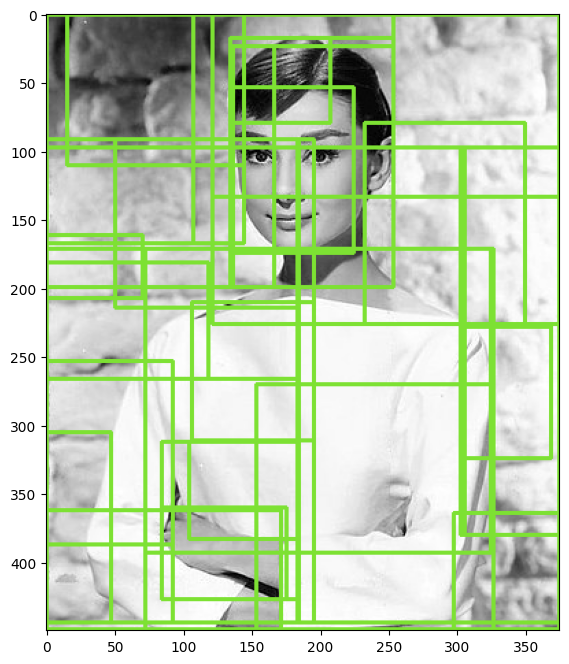

In [29]:
green_rgb = (125,225,51)
img_rgb_copy = img_rgb.copy()
for rect in cand_rects:
    left = rect[0]
    top = rect[1]
    right = left + rect[2]
    bottom = top + rect[3]
    
    img_rgb_copy = cv2.rectangle(img_rgb_copy, (left, top), (right, bottom), green_rgb, 2)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb_copy)
plt.show()


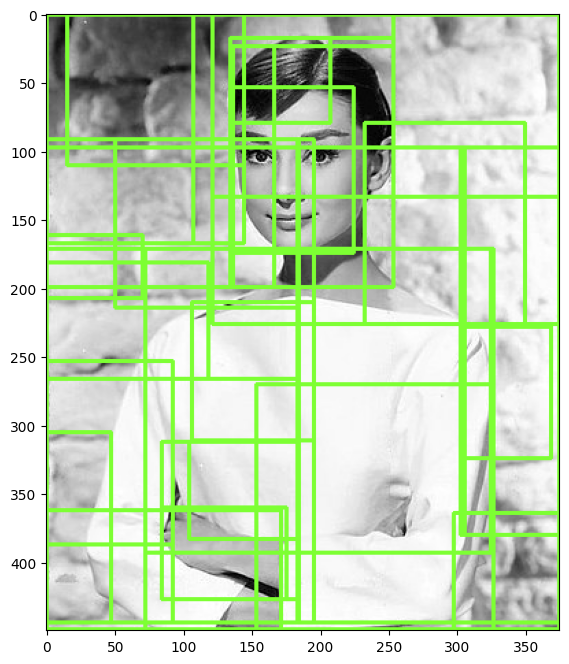

In [30]:
cand_rects = [cand['rect'] for cand in regions if cand['size']>2000]
green_rgb = (125, 255, 51)
img_rgb_copy = img_rgb.copy()
for rect in cand_rects:
    
    left = rect[0]
    top = rect[1]
    # rect[2], rect[3]은 너비와 높이이므로 우하단 좌표를 구하기 위해 좌상단 좌표에 각각을 더함. 
    right = left + rect[2]
    bottom = top + rect[3]
    
    img_rgb_copy = cv2.rectangle(img_rgb_copy, (left, top), (right, bottom), color=green_rgb, thickness=2)
    
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb_copy)
plt.show()